# CAV Methods Comparison: MeanDiff vs HCEP vs HCEP-Filtering vs Filtering

Comparison of four CAV approaches in the context of hierarchical concept relationships:

| Method | Description |
|---|---|
| **MeanDiff** | Standard CAV — difference of class means |
| **HCEP** | Orthogonalises child CAV w.r.t. parent direction |
| **HCEP-Filtering** | Two-stage inference: gate on B first, then score A with `(SV_A − SV_B)` |
| **Filtering** | Trains only on samples where parent = 1 |
| **Baseline** | Logistic regression on raw features — no CAV applied |

Analyses:
1. `|cos_sim(CAV_child, CAV_parent)|` — how entangled each method is with the parent
2. Projection ratio — how much of the parent direction remains in the child CAV
3. Effect of the co-occurrence threshold P(B|A) on cosine similarity
4. AUC comparison — standard, hard negatives, and no-CAV baseline


## 1. Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms as trn
import clip
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

from data_loading import load_sun_data
from dataloaders import create_sun_dataloader
from cav_utils import (
    calculate_centroid_cav,
    calculate_hcep_cav,
    calculate_filtered_cav,
    get_cosine_similarity,
    is_obs_in_concept,
    #is_obs_in_concept_hcep_filtering, ###
    projection_ratio,
    find_optimal_threshold_vectorized,
    PARENTS_THRESHOLDS
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


In [3]:
# Load dataset
df_sun, attributes_list, attr_cols = load_sun_data(
    base_path='data/SUN/SUNAttributeDB', threshold=0.5
)
y_labels = df_sun[attr_cols].values
print(f"Images: {len(df_sun)}  |  Attributes: {len(attr_cols)}")

# Load ResNet18-Places365
model_file = 'models/resnet18_places365.pth'
conv_model = models.resnet18(num_classes=365)
checkpoint  = torch.load(model_file, map_location=lambda s, l: s)
state_dict  = {k.replace('module.', ''): v for k, v in checkpoint['state_dict'].items()}
conv_model.load_state_dict(state_dict)
conv_model.fc = nn.Identity()
conv_model = conv_model.to(DEVICE).eval()

centre_crop = trn.Compose([
    trn.Resize((256, 256)), trn.CenterCrop(224), trn.ToTensor(),
    trn.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load CLIP ViT-B/32
clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()
print(f"CLIP embedding dim: {clip_model.visual.output_dim}")


Images: 14340  |  Attributes: 102
CLIP embedding dim: 512


In [4]:
# Feature extraction dataloaders
dl_resnet = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=centre_crop,
    attr_cols=attr_cols, batch_size=32, num_workers=4
)
dl_clip = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=clip_preprocess,
    attr_cols=attr_cols, batch_size=64, num_workers=4
)

# Extract ResNet18 features
feats_resnet = []
with torch.no_grad():
    for imgs, _, _ in tqdm(dl_resnet, desc="ResNet18 features"):
        feats_resnet.append(conv_model(imgs.to(DEVICE)).cpu().numpy())
X_resnet = np.concatenate(feats_resnet, axis=0)

# Extract CLIP features (L2-normalised)
feats_clip = []
with torch.no_grad():
    for imgs, _, _ in tqdm(dl_clip, desc="CLIP features"):
        f = clip_model.encode_image(imgs.to(DEVICE)).float()
        f = f / f.norm(dim=1, keepdim=True)
        feats_clip.append(f.cpu().numpy())
X_clip = np.concatenate(feats_clip, axis=0)

print(f"ResNet18: {X_resnet.shape}  |  CLIP: {X_clip.shape}")


ResNet18 features:   0%|          | 0/449 [00:00<?, ?it/s]/home/JanTar/miniconda3/envs/automl/lib/python3.11/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv2d(input, weight, bias, self.stride,
CLIP features: 100%|██████████| 225/225 [04:05<00:00,  1.09s/it]


ResNet18: (14340, 512)  |  CLIP: (14340, 512)


In [5]:
# Hierarchical pairs: (child, parent)
all_pairs = [
    # empirical
    ('research',            'enclosed area'),
    ('camping',             'open area'),
    ('medical activity',    'enclosed area'),
    ('gaming',              'enclosed area'),
    ('sand',                'natural light'),
    ('carpet',              'enclosed area'),
    # semantic
    ('ocean',               'open area'),
    ('conducting business', 'working'),
    ('pavement',            'asphalt'),
    ('climbing',            'rock/stone'),
    ('rusty',               'aged/ worn'),
    ('ice',                 'cold'),
]

# Train / test split (consistent with other notebooks)
indices = np.arange(len(df_sun))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

df_meta       = df_sun[attr_cols].reset_index(drop=True)
df_train_meta = df_meta.iloc[train_idx].reset_index(drop=True)
df_test_meta  = df_meta.iloc[test_idx].reset_index(drop=True)

feature_sets = {
    "ResNet18": (X_resnet[train_idx], X_resnet[test_idx], X_resnet),
    "CLIP":     (X_clip[train_idx],   X_clip[test_idx],   X_clip),
}

# Colors for CAV methods (Baseline added separately in AUC section)
METHOD_COLORS = {
    "MeanDiff":       "#4C72B0",
    "HCEP":           "#DD8452",
    "HCEP-Filtering": "#55A868",
    "Filtering":      "#C44E52",
}
METHODS = list(METHOD_COLORS.keys())
print("Setup complete.")


Setup complete.


## 2. Compute CAVs for all methods and pairs

In [6]:
def calculate_hcep_filtering_cav(cav_child_md, cav_parent_md):
    """HCEP-Filtering: normalised difference (SV_A - SV_B).
    Orthogonal to SV_B when SV_B = proj(SV_A -> SV_B).
    """
    diff = cav_child_md - cav_parent_md
    norm = np.linalg.norm(diff)
    if norm < 1e-10:
        raise ValueError("SV_A - SV_B ≈ 0 — concepts may be identical")
    return diff / norm


def compute_all_cavs(features, df, pairs):
    """
    Returns a DataFrame with |cos_sim| and proj_ratio for all 4 methods
    and every (child, parent) pair.

    proj_ratio uses projection_ratio() from cav_utils:
        projection_ratio(cav, parent) = dot(cav, parent)²
    For normalised vectors this equals cos_sim².
    """
    records = []
    for child, parent in pairs:
        idx_cp = df.index[df[child]  == 1.0].tolist()
        idx_cn = df.index[df[child]  == 0.0].tolist()
        idx_pp = df.index[df[parent] == 1.0].tolist()
        idx_pn = df.index[df[parent] == 0.0].tolist()

        try:
            cav_parent  = calculate_centroid_cav(features, idx_pp, idx_pn)
            cav_md      = calculate_centroid_cav(features, idx_cp, idx_cn)
            cav_hcep    = calculate_hcep_cav(features, idx_cp, idx_cn, parent_cav=cav_parent)
            cav_hcep_f  = calculate_hcep_filtering_cav(cav_md, cav_parent)
            cav_filt    = calculate_filtered_cav(features, idx_cp, idx_cn, idx_pp)
        except ValueError as e:
            print(f"  [SKIPPED] {child}: {e}")
            continue

        for method, cav in [
            ("MeanDiff",       cav_md),
            ("HCEP",           cav_hcep),
            ("HCEP-Filtering", cav_hcep_f),
            ("Filtering",      cav_filt),
        ]:
            cs = get_cosine_similarity(cav, cav_parent)
            pr = projection_ratio(cav, cav_parent)
            records.append({
                "Child":       child,
                "Parent":      parent,
                "Method":      method,
                "cos_sim":     round(cs,  5),
                "abs_cos_sim": round(abs(cs), 5),
                "proj_ratio":  round(pr,  5),
            })
    return pd.DataFrame(records)


print("Computing CAVs...")
dfs_cav = {}
for model_name, (X_tr, X_te, X_full) in feature_sets.items():
    dfs_cav[model_name] = compute_all_cavs(X_full, df_meta, all_pairs)
    dfs_cav[model_name]["Model"] = model_name
    print(f"  {model_name}: {len(dfs_cav[model_name])} records")

df_cav_all = pd.concat(dfs_cav.values(), ignore_index=True)
print("Done.")

Computing CAVs...
  ResNet18: 48 records
  CLIP: 48 records
Done.


## 3. |cos_sim(CAV_child, CAV_parent)|

Absolute cosine similarity between child and parent CAVs.  
Lower = more independent from the parent direction.


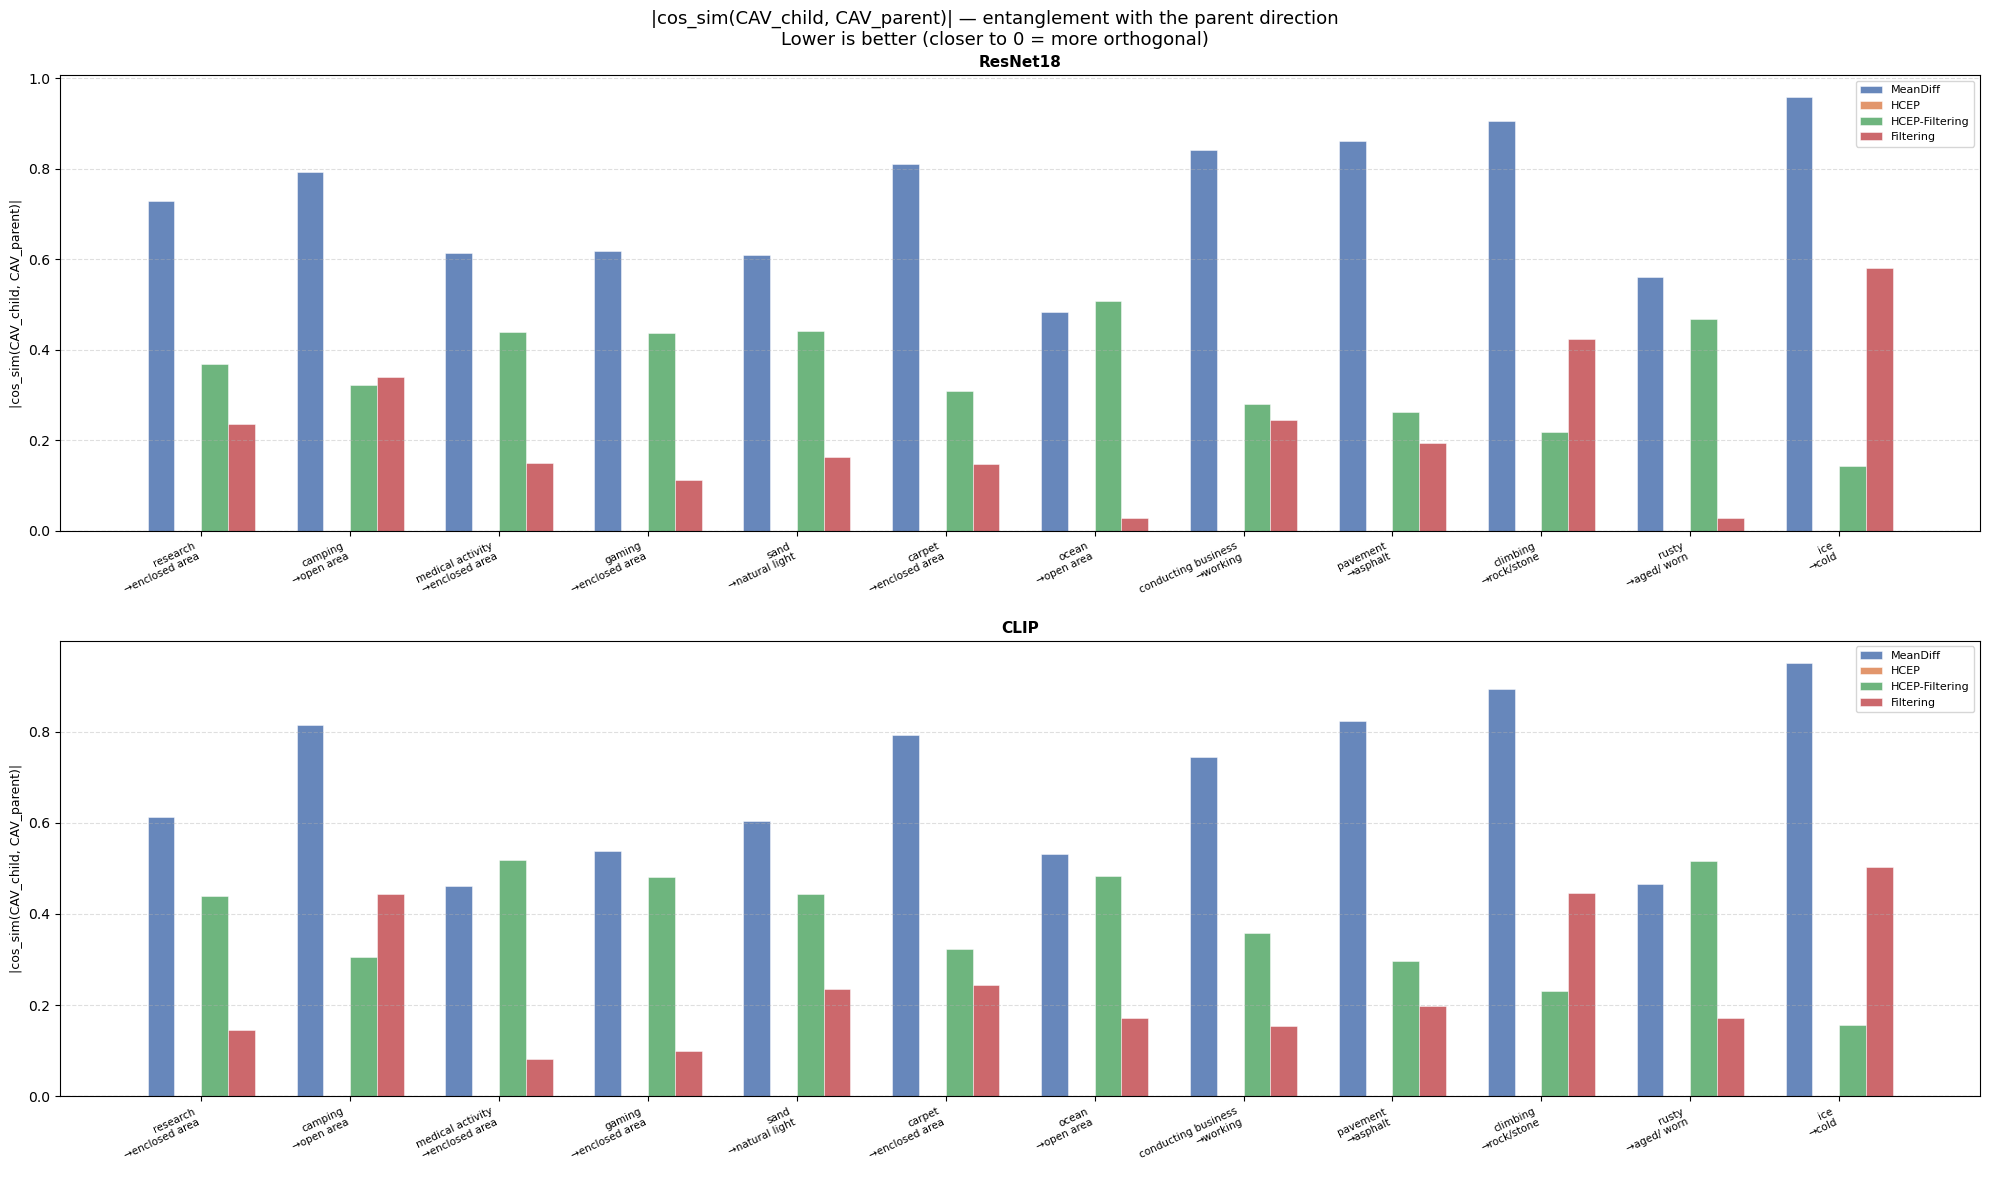

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12), sharey=False)

for ax, model_name in zip(axes, ["ResNet18", "CLIP"]):
    sub    = df_cav_all[df_cav_all["Model"] == model_name]
    valid  = [(c, p) for c, p in all_pairs
               if len(sub[(sub["Child"] == c) & (sub["Parent"] == p)]) > 0]
    labels = [f"{c}\n→{p}" for c, p in valid]
    x      = np.arange(len(labels))
    w      = 0.18
    offsets = np.linspace(-(len(METHODS)-1)/2*w, (len(METHODS)-1)/2*w, len(METHODS))

    for offset, method in zip(offsets, METHODS):
        vals = []
        for c, p in valid:
            row = sub[(sub["Child"] == c) & (sub["Parent"] == p) & (sub["Method"] == method)]
            vals.append(row["abs_cos_sim"].values[0] if len(row) else np.nan)
        ax.bar(x + offset, vals, w, label=method,
               color=METHOD_COLORS[method], alpha=0.85, edgecolor="white", lw=0.4)

    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7.5, rotation=25, ha="right")
    ax.set_ylabel("|cos_sim(CAV_child, CAV_parent)|", fontsize=9)
    ax.set_title(model_name, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(axis="y", ls="--", alpha=0.4)

fig.suptitle(
    "|cos_sim(CAV_child, CAV_parent)| — entanglement with the parent direction\n"
    "Lower is better (closer to 0 = more orthogonal)",
    fontsize=13
)
plt.tight_layout()
plt.show()


## 4. Projection ratio

`projection_ratio = dot(CAV_child, CAV_parent)²`  
How much of the parent direction remains in the child CAV.  
0 = fully orthogonal, 1 = fully aligned with parent.


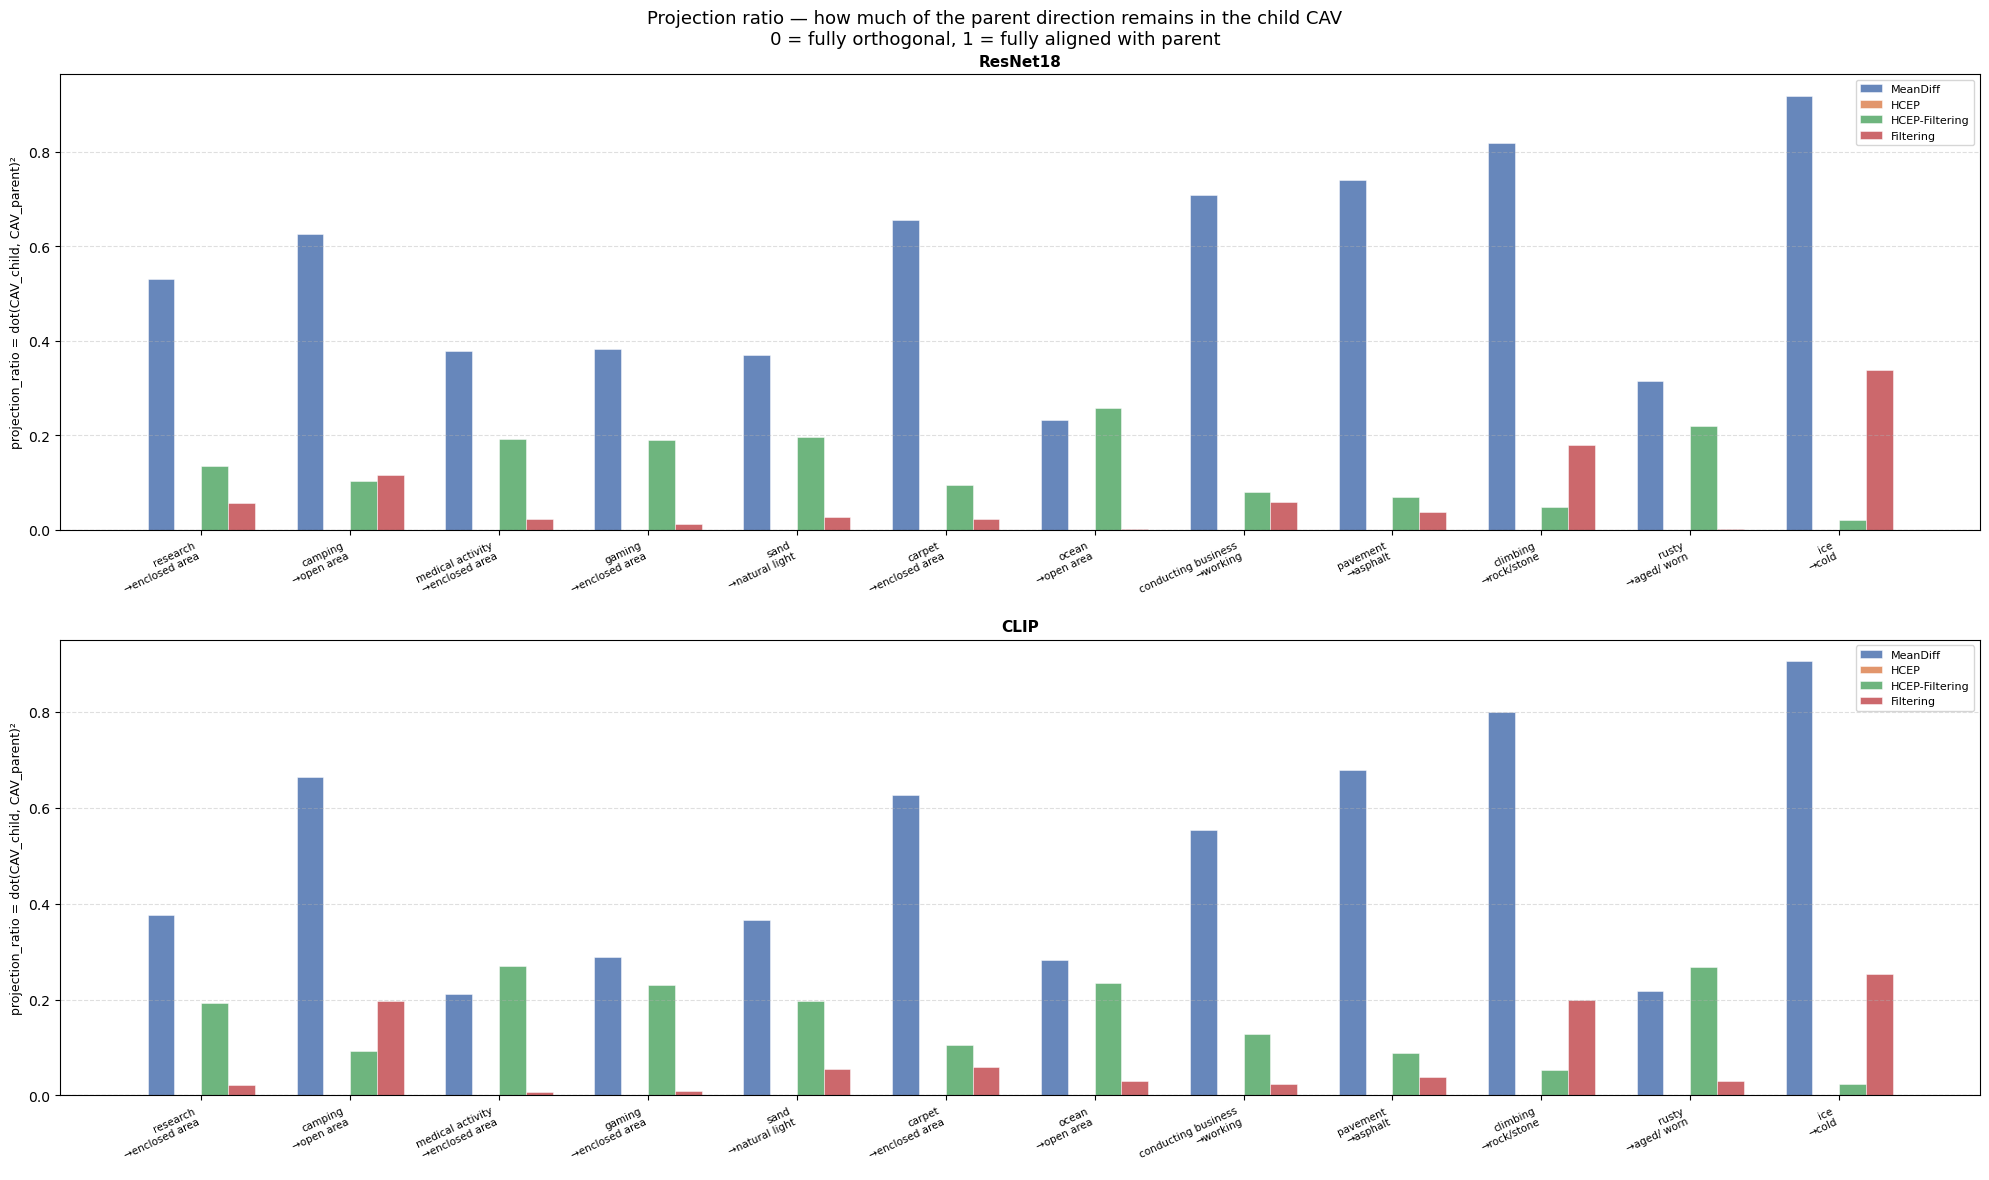

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12), sharey=False)

for ax, model_name in zip(axes, ["ResNet18", "CLIP"]):
    sub    = df_cav_all[df_cav_all["Model"] == model_name]
    valid  = [(c, p) for c, p in all_pairs
               if len(sub[(sub["Child"] == c) & (sub["Parent"] == p)]) > 0]
    labels = [f"{c}\n→{p}" for c, p in valid]
    x      = np.arange(len(labels))
    w      = 0.18
    offsets = np.linspace(-(len(METHODS)-1)/2*w, (len(METHODS)-1)/2*w, len(METHODS))

    for offset, method in zip(offsets, METHODS):
        vals = []
        for c, p in valid:
            row = sub[(sub["Child"] == c) & (sub["Parent"] == p) & (sub["Method"] == method)]
            vals.append(row["proj_ratio"].values[0] if len(row) else np.nan)
        ax.bar(x + offset, vals, w, label=method,
               color=METHOD_COLORS[method], alpha=0.85, edgecolor="white", lw=0.4)

    ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7.5, rotation=25, ha="right")
    ax.set_ylabel("projection_ratio = dot(CAV_child, CAV_parent)²", fontsize=9)
    ax.set_title(model_name, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(axis="y", ls="--", alpha=0.4)

fig.suptitle(
    "Projection ratio — how much of the parent direction remains in the child CAV\n"
    "0 = fully orthogonal, 1 = fully aligned with parent",
    fontsize=13
)
plt.tight_layout()
plt.show()


## 5. Effect of P(B|A) on |cos_sim|

Subsets with increasing co-occurrence P(B|A) are generated and  
`|cos_sim(CAV_child, CAV_parent)|` is measured for all 4 methods.

> **Expected:** MeanDiff rises with P(B|A). HCEP and HCEP-Filtering stay near 0.


In [9]:
np.random.seed(42)
TARGET_PROBS = np.round(np.arange(0.50, 1.01, 0.02), 2)


def generate_ablation_subsets(y_labels, a_idx, b_idx, target_probs):
    """Build training subsets with controlled P(B|A) values."""
    idx_ab   = np.where((y_labels[:, a_idx] == 1) & (y_labels[:, b_idx] == 1))[0]
    idx_a_nb = np.where((y_labels[:, a_idx] == 1) & (y_labels[:, b_idx] == 0))[0]
    count_ab = len(idx_ab)
    subsets  = {}
    for p in target_probs:
        keep = 0 if p >= 1.0 else int(count_ab * (1 - p) / p)
        keep = min(keep, len(idx_a_nb))
        kept = np.random.choice(idx_a_nb, keep, replace=False) if keep > 0 else np.array([])
        subsets[p] = np.concatenate([idx_ab, kept]).astype(int)
    return subsets


def run_ablation_all_methods(features, y_labels, attr_cols, pairs, model_label):
    """Run the P(B|A) ablation for all 4 methods across all pairs."""
    records = []
    for child, parent in pairs:
        if child not in attr_cols or parent not in attr_cols:
            continue
        a_idx = attr_cols.index(child)
        b_idx = attr_cols.index(parent)

        idx_not_a = np.where(y_labels[:, a_idx] == 0)[0]
        idx_pp    = np.where(y_labels[:, b_idx] == 1)[0]
        idx_pn    = np.where(y_labels[:, b_idx] == 0)[0]
        try:
            cav_parent = calculate_centroid_cav(features, idx_pp, idx_pn)
        except ValueError:
            continue

        for p, idx_a in generate_ablation_subsets(y_labels, a_idx, b_idx, TARGET_PROBS).items():
            if len(idx_a) < 5:
                continue
            try:
                cav_md     = calculate_centroid_cav(features, idx_a, idx_not_a)
                cav_hcep   = calculate_hcep_cav(features, idx_a, idx_not_a, parent_cav=cav_parent)
                cav_hcep_f = calculate_hcep_filtering_cav(cav_md, cav_parent)
                cav_filt   = calculate_filtered_cav(features, idx_a, idx_not_a, idx_pp)
            except ValueError:
                continue

            for method, cav in [
                ("MeanDiff",       cav_md),
                ("HCEP",           cav_hcep),
                ("HCEP-Filtering", cav_hcep_f),
                ("Filtering",      cav_filt),
            ]:
                records.append({
                    "Model":       model_label,
                    "Child":       child,
                    "Parent":      parent,
                    "Method":      method,
                    "P(B|A)":      round(float(p), 3),
                    "abs_cos_sim": abs(get_cosine_similarity(cav, cav_parent)),
                })
    return pd.DataFrame(records)


print("Running ablation for ResNet18...")
df_abl_resnet = run_ablation_all_methods(X_resnet, y_labels, attr_cols, all_pairs, "ResNet18")
print(f"  {len(df_abl_resnet)} points")

print("Running ablation for CLIP...")
df_abl_clip = run_ablation_all_methods(X_clip, y_labels, attr_cols, all_pairs, "CLIP")
print(f"  {len(df_abl_clip)} points")

df_abl = pd.concat([df_abl_resnet, df_abl_clip], ignore_index=True)
print("Done.")


Running ablation for ResNet18...
  1248 points
Running ablation for CLIP...
  1248 points
Done.


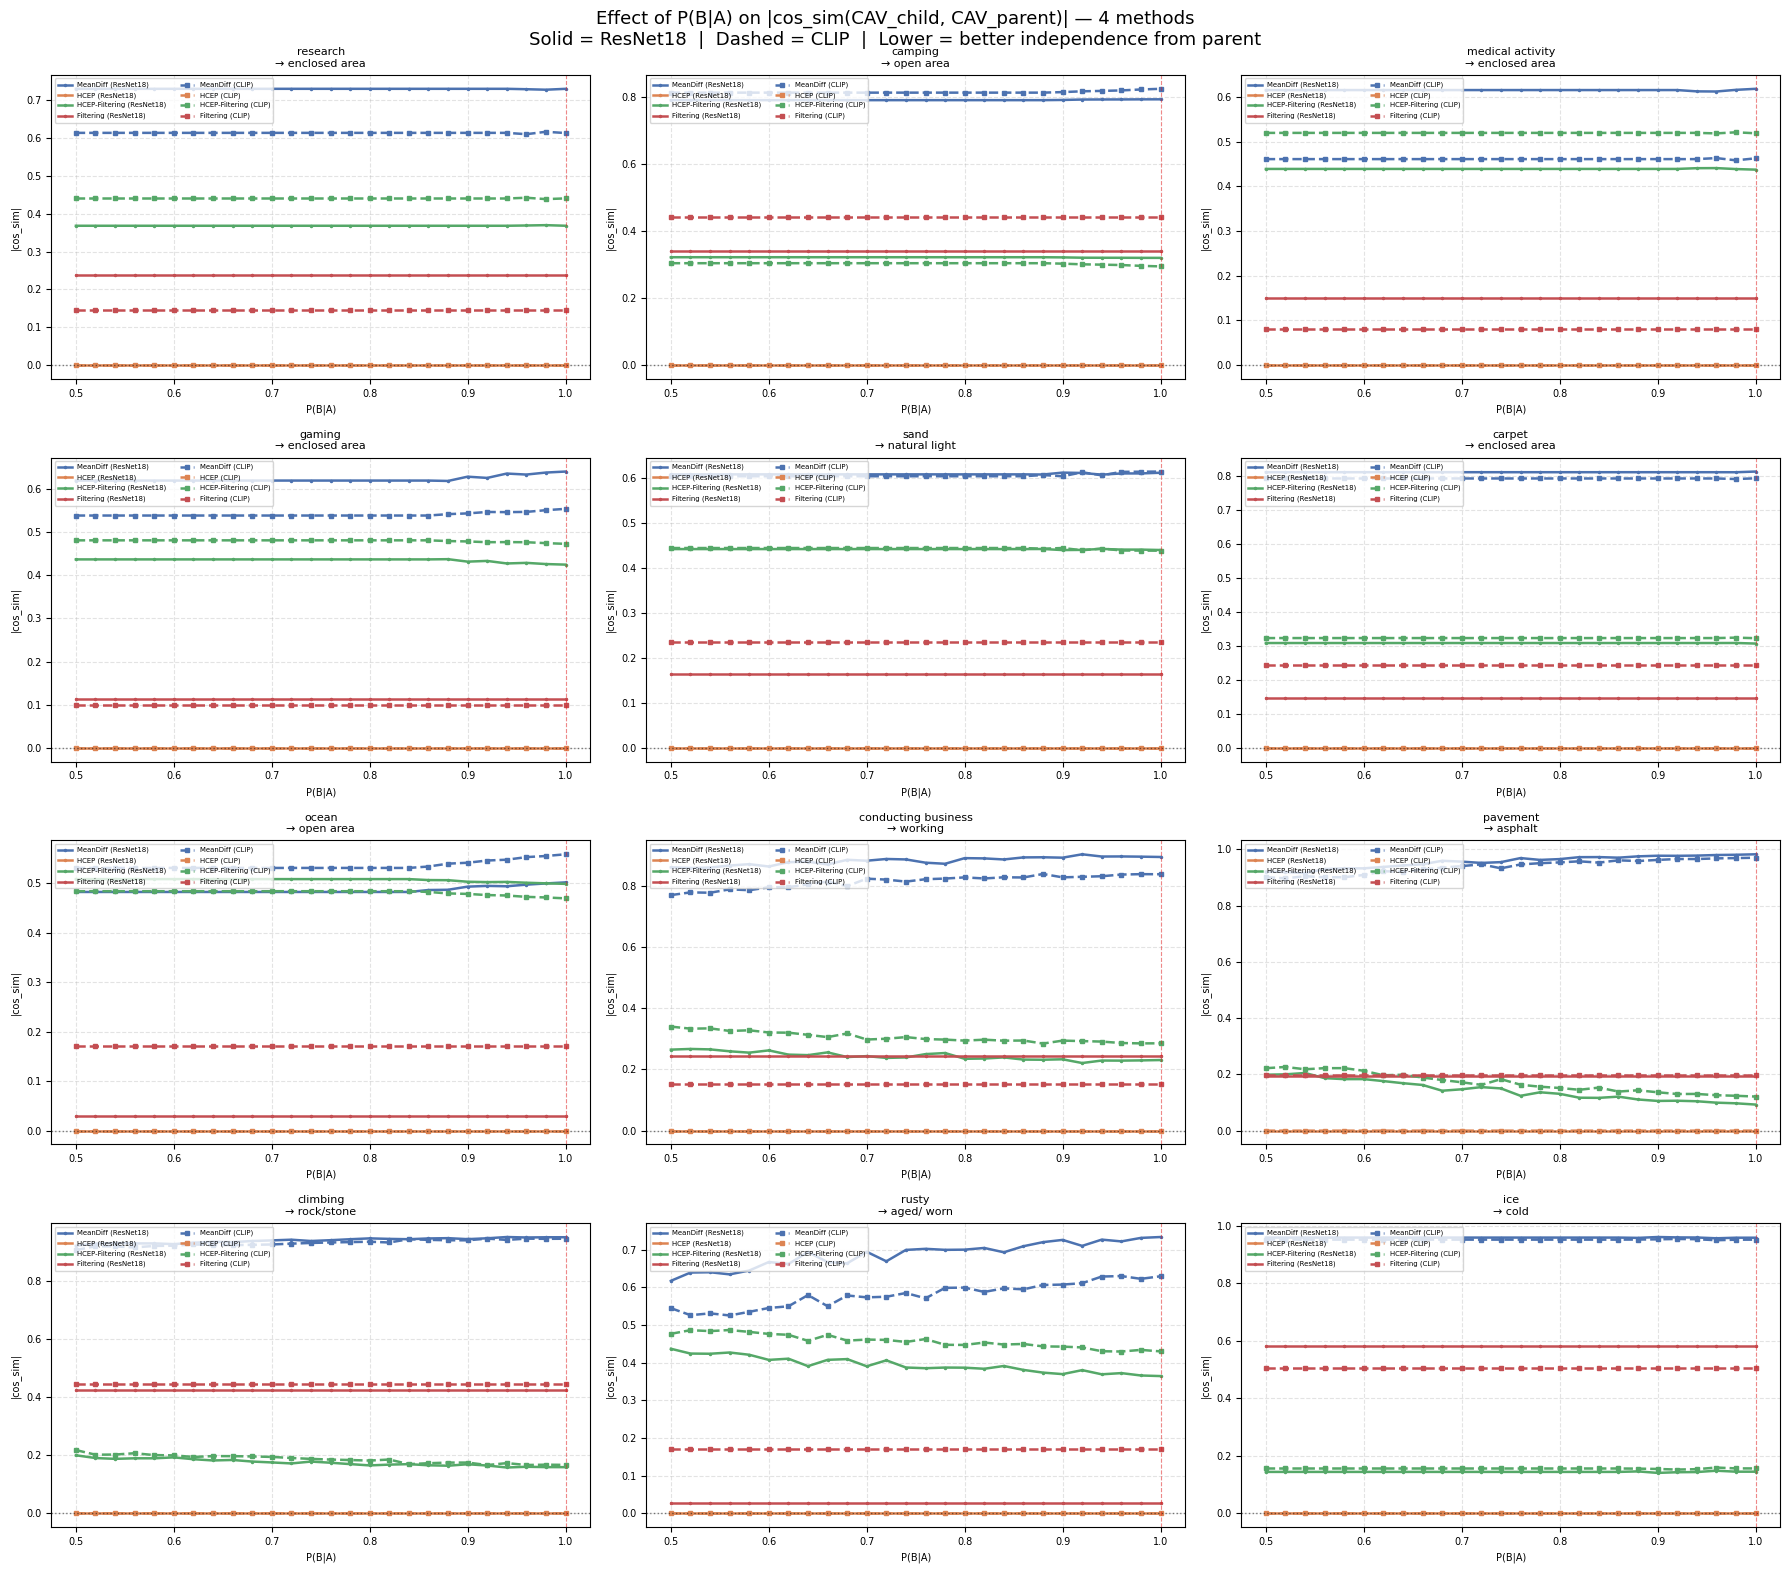

In [10]:
# Line plots — one subplot per pair, both models overlaid
n_cols = 3
n_rows = (len(all_pairs) + n_cols - 1) // n_cols
MODEL_LS = {"ResNet18": "-", "CLIP": "--"}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4))
axes_flat = axes.flatten()

for i, (child, parent) in enumerate(all_pairs):
    ax = axes_flat[i]
    for model_name, ls in MODEL_LS.items():
        for method in METHODS:
            sub = df_abl[
                (df_abl["Model"]  == model_name) &
                (df_abl["Child"]  == child) &
                (df_abl["Parent"] == parent) &
                (df_abl["Method"] == method)
            ].sort_values("P(B|A)")
            if sub.empty:
                continue
            marker = "." if model_name == "ResNet18" else "s"
            ax.plot(sub["P(B|A)"], sub["abs_cos_sim"],
                    color=METHOD_COLORS[method], ls=ls,
                    lw=1.8, marker=marker, markersize=3,
                    label=f"{method} ({model_name})")

    ax.axhline(0, color="black", ls=":", lw=1, alpha=0.5)
    ax.axvline(1, color="red",   ls="--", lw=0.8, alpha=0.4)
    ax.set_title(f"{child}\n→ {parent}", fontsize=8)
    ax.set_xlabel("P(B|A)", fontsize=7)
    ax.set_ylabel("|cos_sim|", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=5, loc="upper left", ncol=2)
    ax.grid(True, ls="--", alpha=0.35)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle(
    "Effect of P(B|A) on |cos_sim(CAV_child, CAV_parent)| — 4 methods\n"
    "Solid = ResNet18  |  Dashed = CLIP  |  Lower = better independence from parent",
    fontsize=13
)
plt.tight_layout()
plt.show()


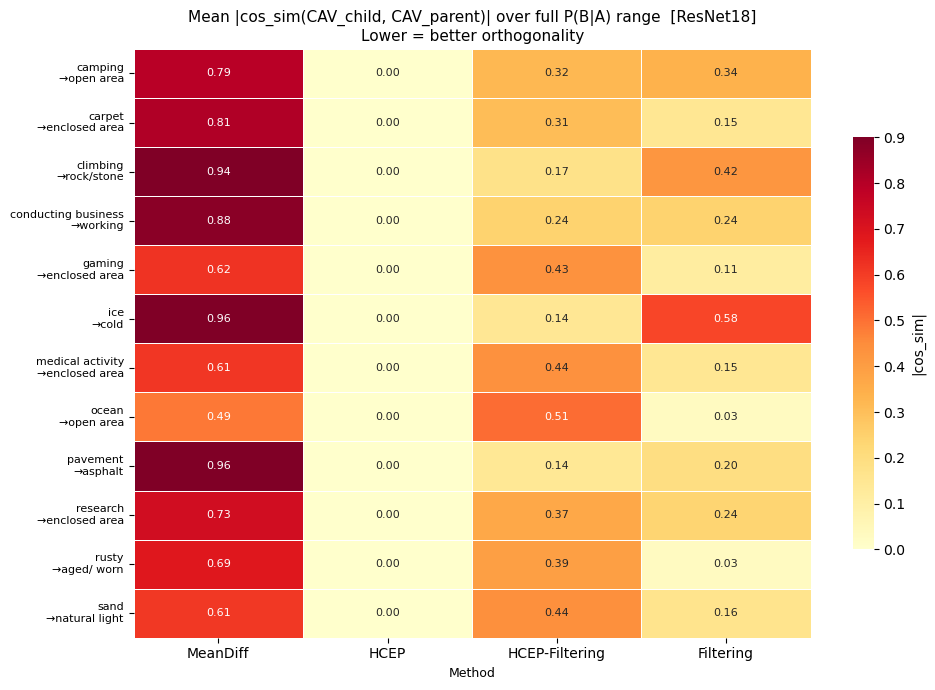

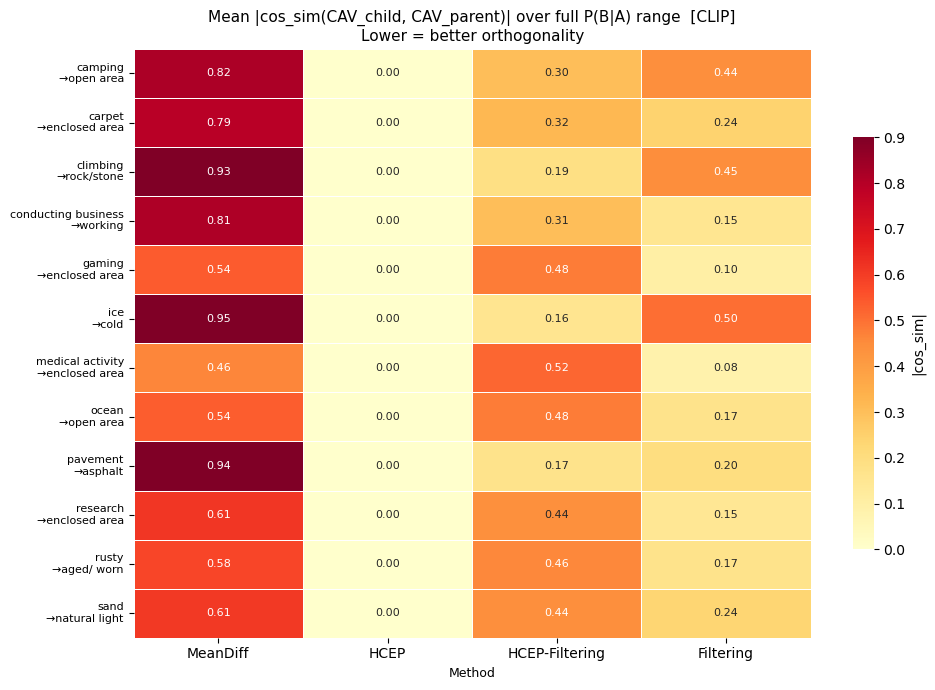

In [11]:
# Heatmap — mean |cos_sim| averaged over the full P(B|A) range, per pair × method
for model_name in ["ResNet18", "CLIP"]:
    sub = df_abl[df_abl["Model"] == model_name].copy()
    sub["Pair"] = sub["Child"] + "\n→" + sub["Parent"]

    pivot = sub.groupby(["Pair", "Method"])["abs_cos_sim"].mean().unstack("Method")[METHODS]

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(
        pivot, ax=ax,
        cmap="YlOrRd", vmin=0, vmax=0.9,
        annot=True, fmt=".2f", annot_kws={"size": 8},
        linewidths=0.4, cbar_kws={"shrink": 0.7, "label": "|cos_sim|"}
    )
    ax.set_title(
        f"Mean |cos_sim(CAV_child, CAV_parent)| over full P(B|A) range  [{model_name}]\n"
        "Lower = better orthogonality",
        fontsize=11
    )
    ax.set_xlabel("Method", fontsize=9)
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    plt.show()


## 6. AUC comparison — standard test set

AUC for all 4 CAV methods + logistic regression baseline (no CAV applied),
evaluated on the full test set.


In [12]:
ALL_METHODS_AUC = ["MeanDiff", "HCEP", "HCEP-Filtering", "Filtering", "Baseline"]
SHORT = {"MeanDiff": "MD", "HCEP": "HCEP", "HCEP-Filtering": "HCEP-F",
         "Filtering": "Filt", "Baseline": "Base"}


def evaluate_auc_standard(X_train, X_test, df_train, df_test, pairs, model_name):
    """
    Standard AUC on the full test set.

    AUC measures how well cosine_similarity(image_features, CAV) separates
    child=1 from child=0 across all test images.

    HCEP-Filtering uses two-stage gated inference:
      score_B = cosine_similarity(x, cav_parent)
      if score_B <= 0  ->  final_score = -1   (B absent => A absent)
      if score_B >  0  ->  final_score = cosine_similarity(x, SV_A - SV_B)
    """
    records = []
    for child, parent in pairs:
        idx_cp_tr = df_train.index[df_train[child]  == 1.0].tolist()
        idx_cn_tr = df_train.index[df_train[child]  == 0.0].tolist()
        idx_pp_tr = df_train.index[df_train[parent] == 1.0].tolist()
        idx_pn_tr = df_train.index[df_train[parent] == 0.0].tolist()

        try:
            cav_parent = calculate_centroid_cav(X_train, idx_pp_tr, idx_pn_tr)
            cav_md     = calculate_centroid_cav(X_train, idx_cp_tr, idx_cn_tr)
            cav_hcep   = calculate_hcep_cav(X_train, idx_cp_tr, idx_cn_tr, parent_cav=cav_parent)
            cav_hcep_f = calculate_hcep_filtering_cav(cav_md, cav_parent)
            cav_filt   = calculate_filtered_cav(X_train, idx_cp_tr, idx_cn_tr, idx_pp_tr)
        except ValueError as e:
            print(f"  [SKIPPED] {child}: {e}")
            continue

        y_te = df_test[child].values
        if len(np.unique(y_te)) < 2:
            continue

        row = {"Model": model_name, "Child": child, "Parent": parent}


        # calculating threshold for parent gating
        if parent in PARENTS_THRESHOLDS:
            t_parent = PARENTS_THRESHOLDS[parent]
        else:
            # Fallback
            y_train_parent = df_train[parent].values
            t_parent = find_optimal_threshold_vectorized(X_train, y_train_parent, cav_parent)

        # detecting parent presence in test set
        sim_parent = cosine_similarity(X_test, cav_parent.reshape(1, -1)).flatten()
        parent_mask = sim_parent >= t_parent

        for method, cav in [("MeanDiff", cav_md), 
                            ("HCEP", cav_hcep), 
                            ("Filtering", cav_filt)]:
            sim_child = cosine_similarity(X_test, cav.reshape(1, -1)).flatten()
            final_scores = np.where(parent_mask, sim_child, -1.0)
            #row[method] = round(roc_auc_score(y_te, s), 3) # old
            row[method] = round(roc_auc_score(y_te, final_scores), 3) # new

        # HCEP-Filtering: two-stage gating
        s_b      = cosine_similarity(X_test, cav_parent.reshape(1,-1)).flatten()
        s_af     = cosine_similarity(X_test, cav_hcep_f.reshape(1,-1)).flatten()
        row["HCEP-Filtering"] = round(roc_auc_score(y_te, np.where(s_b > 0, s_af, -1.0)), 3)

        # Baseline: logistic regression — no CAV
        try:
            lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
            lr.fit(X_train, df_train[child].values.astype(int))
            row["Baseline"] = round(roc_auc_score(y_te, lr.predict_proba(X_test)[:, 1]), 3)
        except Exception:
            row["Baseline"] = None

        records.append(row)
    return pd.DataFrame(records)


print("Computing standard AUC...")
auc_std_dfs = []
for model_name, (X_tr, X_te, _) in feature_sets.items():
    auc_std_dfs.append(evaluate_auc_standard(
        X_tr, X_te, df_train_meta, df_test_meta, all_pairs, model_name
    ))
    print(f"  {model_name}: done")

df_auc_std = pd.concat(auc_std_dfs, ignore_index=True)
print("Done.")


Computing standard AUC...


  ResNet18: done
  CLIP: done
Done.


In [13]:
# for model_name in ["ResNet18", "CLIP"]:
#     sub  = df_auc_std[df_auc_std["Model"] == model_name]
#     cols = ["Child", "Parent"] + [m for m in ALL_METHODS_AUC if m in sub.columns]
#     rename = {m: SHORT[m] for m in ALL_METHODS_AUC}
#     print(f"\n{'='*80}")
#     print(f"  AUC (standard) — {model_name.upper()}")
#     print(f"{'='*80}")
#     print(sub[cols].rename(columns=rename).to_string(index=False))


In [14]:
# Precompute pair statistics
def get_pair_stats(df, pairs):
    rows = {}
    for child, parent in pairs:
        n_a  = int(df[child].sum())
        n_b  = int(df[parent].sum())
        n_ab = int(((df[child] == 1.0) & (df[parent] == 1.0)).sum())
        rows[(child, parent)] = {
        "P(B|A)": round(n_ab / n_a, 2) if n_a > 0 else None,
        "P(A|B)": round(n_ab / n_b, 2) if n_b > 0 else None,
        "n_A":    n_a,
        "n_B":    n_b,
    }
    return rows

pair_stats = get_pair_stats(df_meta, all_pairs)

for model_name in ["ResNet18", "CLIP"]:
    sub  = df_auc_std[df_auc_std["Model"] == model_name].copy()

    sub["P(B|A)"] = sub.apply(lambda r: pair_stats[(r["Child"], r["Parent"])]["P(B|A)"], axis=1)
    sub["P(A|B)"] = sub.apply(lambda r: pair_stats[(r["Child"], r["Parent"])]["P(A|B)"], axis=1)
    sub["n_A"]    = sub.apply(lambda r: pair_stats[(r["Child"], r["Parent"])]["n_A"],    axis=1)
    sub["n_B"]    = sub.apply(lambda r: pair_stats[(r["Child"], r["Parent"])]["n_B"],    axis=1)

    cols   = ["Child", "Parent", "P(B|A)", "P(A|B)", "n_A", "n_B"] +              [m for m in ALL_METHODS_AUC if m in sub.columns]
    rename = {m: SHORT[m] for m in ALL_METHODS_AUC}

    print(f"\n{'='*110}")
    print(f"  AUC (standard) — {model_name.upper()}")
    print(f"{'='*110}")
    print(sub[cols].sort_values("P(B|A)", ascending=False).rename(columns=rename).to_string(index=False))



  AUC (standard) — RESNET18
              Child        Parent  P(B|A)  P(A|B)  n_A  n_B    MD  HCEP  HCEP-F  Filt  Base
             carpet enclosed area    0.96    0.06  324 4947 0.914 0.908   0.877 0.910 0.913
           research enclosed area    0.95    0.04  207 4947 0.958 0.958   0.941 0.958 0.945
   medical activity enclosed area    0.92    0.02  118 4947 0.980 0.980   0.968 0.981 0.984
            camping     open area    0.89    0.14  871 5541 0.956 0.954   0.949 0.958 0.959
             gaming enclosed area    0.88    0.02  108 4947 0.949 0.946   0.956 0.948 0.909
                ice          cold    0.88    0.36  158  388 0.846 0.845   0.936 0.845 0.992
               sand natural light    0.87    0.05  351 6709 0.919 0.925   0.898 0.922 0.963
              ocean     open area    0.85    0.06  413 5541 0.870 0.870   0.868 0.870 0.980
conducting business       working    0.40    0.10  263 1032 0.872 0.859   0.780 0.851 0.879
           climbing    rock/stone    0.36    0.39  

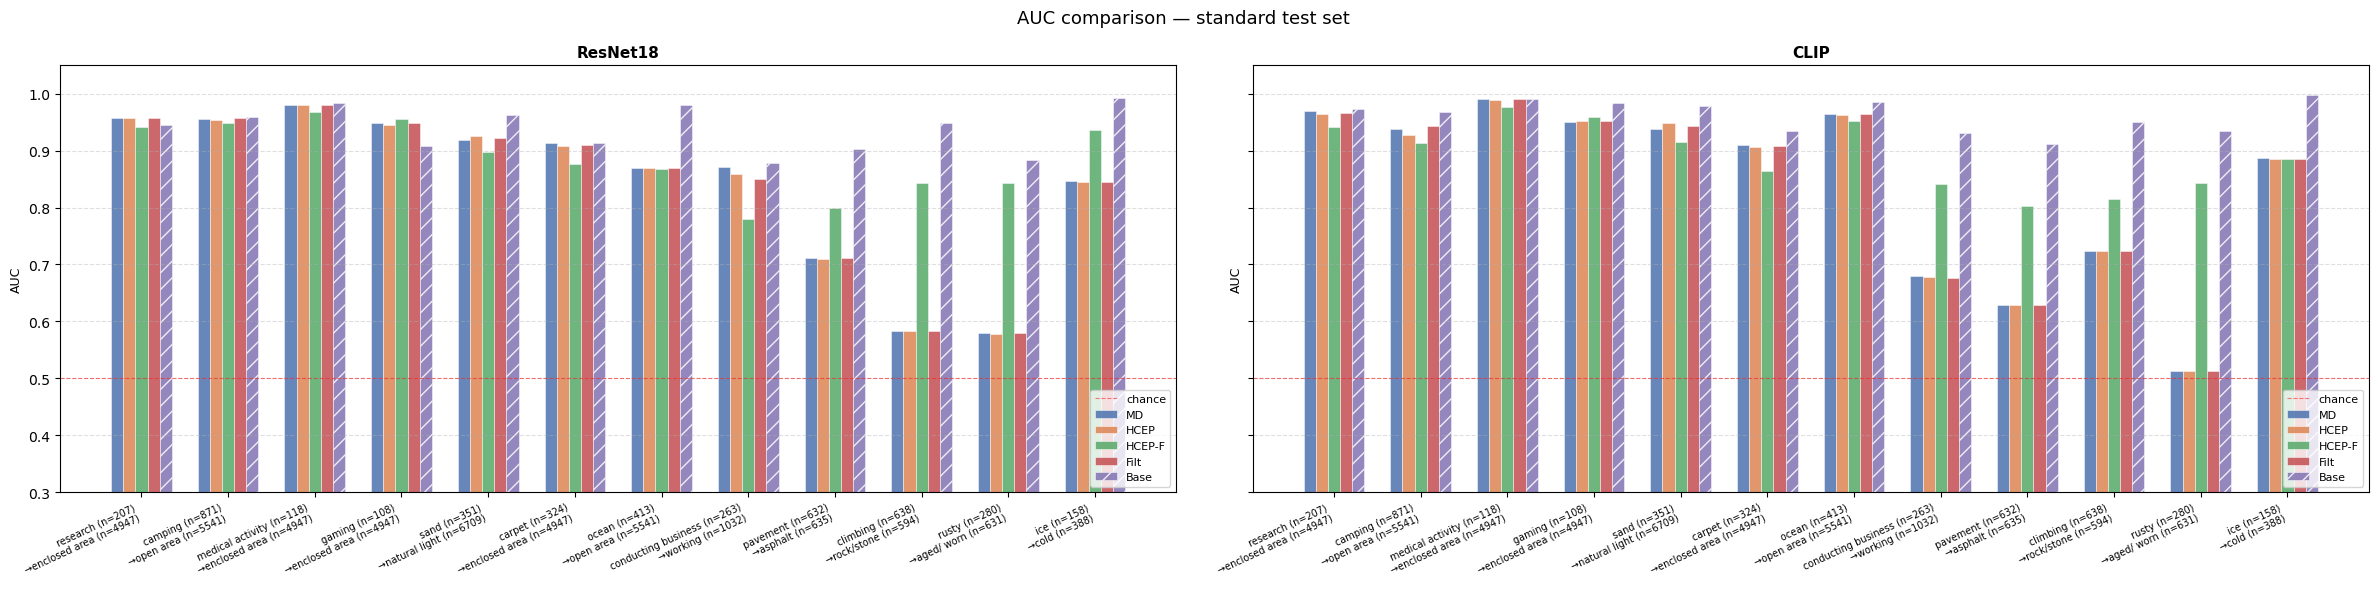

In [15]:
ALL_COLORS = {**METHOD_COLORS, "Baseline": "#8172B2"}

# Precompute sample counts from full dataset
pair_counts = {
    (c, p): (int(df_meta[c].sum()), int(df_meta[p].sum()))
    for c, p in all_pairs
}

fig, axes = plt.subplots(1, 2, figsize=(24, 6), sharey=True)

for ax, model_name in zip(axes, ["ResNet18", "CLIP"]):
    sub     = df_auc_std[df_auc_std["Model"] == model_name]
    labels  = [
        f"{r['Child']} (n={pair_counts[(r['Child'], r['Parent'])][0]})\n"
        f"→{r['Parent']} (n={pair_counts[(r['Child'], r['Parent'])][1]})"
        for _, r in sub.iterrows()
    ]
    x       = np.arange(len(labels))
    w       = 0.14
    offsets = np.linspace(-(len(ALL_METHODS_AUC)-1)/2*w,
                           (len(ALL_METHODS_AUC)-1)/2*w, len(ALL_METHODS_AUC))

    for offset, method in zip(offsets, ALL_METHODS_AUC):
        if method not in sub.columns:
            continue
        vals  = pd.to_numeric(sub[method], errors="coerce").fillna(0).values
        hatch = "//" if method == "Baseline" else None
        ax.bar(x + offset, vals, w, label=SHORT[method],
               color=ALL_COLORS[method], alpha=0.85, edgecolor="white", lw=0.4, hatch=hatch)

    ax.axhline(0.5, color="red", lw=0.8, ls="--", alpha=0.5, label="chance")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7, rotation=25, ha="right")
    ax.set_title(model_name, fontsize=11, fontweight="bold")
    ax.set_ylabel("AUC", fontsize=9)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="y", ls="--", alpha=0.4)
    ax.set_ylim(0.3, 1.05)

fig.suptitle("AUC comparison — standard test set", fontsize=13)
plt.tight_layout()
plt.show()


## 7. AUC comparison — hard negatives (parent = 1)

Same evaluation but restricted to test samples where `parent = 1`.
This is a harder test: the model must distinguish `child=1` from `child=0`
within the parent context, not from completely unrelated images.


In [16]:
# def run_evaluation_hard(X_train, X_test, df_train, df_test, pairs, model_name):
#     """
#     Hard-negatives AUC: test set filtered to parent = 1 only.
#     Sorted by Δ(best_CAV - MeanDiff), descending.
#     """
#     print("\n" + "=" * 130)
#     print(f"  EVALUATION (hard negatives) — {model_name.upper()}")
#     print("=" * 130)
#     print(f"{'CHILD':<22} | {'PARENT':<18} | "
#           f"{'MD':>6} | {'HCEP':>6} | {'HCEP-F':>7} | "
#           f"{'Filt':>6} | {'Base':>6} | {'Best':>12} | {'Δ(best-MD)':>10}")
#     print("-" * 130)

#     results = []
#     for child, parent in pairs:
#         idx_cp_tr = df_train.index[df_train[child]  == 1.0].tolist()
#         idx_cn_tr = df_train.index[df_train[child]  == 0.0].tolist()
#         idx_pp_tr = df_train.index[df_train[parent] == 1.0].tolist()
#         idx_pn_tr = df_train.index[df_train[parent] == 0.0].tolist()

#         try:
#             cav_parent = calculate_centroid_cav(X_train, idx_pp_tr, idx_pn_tr)
#             cav_md     = calculate_centroid_cav(X_train, idx_cp_tr, idx_cn_tr)
#             cav_hcep   = calculate_hcep_cav(X_train, idx_cp_tr, idx_cn_tr, parent_cav=cav_parent)
#             cav_hcep_f = calculate_hcep_filtering_cav(cav_md, cav_parent)
#             cav_filt   = calculate_filtered_cav(X_train, idx_cp_tr, idx_cn_tr, idx_pp_tr)
#         except ValueError as e:
#             print(f"{child:<22} | {parent:<18} | [SKIPPED: {e}]")
#             continue

#         hard_mask = (df_test[parent] == 1.0).values
#         y_hard    = df_test[child].values[hard_mask]
#         X_hard    = X_test[hard_mask]

#         if len(np.unique(y_hard)) < 2:
#             print(f"{child:<22} | {parent:<18} | --- too few samples in hard set ---")
#             continue

#         s_md   = cosine_similarity(X_hard, cav_md.reshape(1,-1)).flatten()
#         s_hcep = cosine_similarity(X_hard, cav_hcep.reshape(1,-1)).flatten()
#         s_filt = cosine_similarity(X_hard, cav_filt.reshape(1,-1)).flatten()

#         s_b_h  = cosine_similarity(X_hard, cav_parent.reshape(1,-1)).flatten()
#         s_af_h = cosine_similarity(X_hard, cav_hcep_f.reshape(1,-1)).flatten()
#         s_gate = np.where(s_b_h > 0, s_af_h, -1.0)

#         try:
#             lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
#             lr.fit(X_train, df_train[child].values.astype(int))
#             s_base = lr.predict_proba(X_hard)[:, 1]
#         except Exception:
#             s_base = None

#         auc = {
#             "MeanDiff":       round(roc_auc_score(y_hard, s_md),   3),
#             "HCEP":           round(roc_auc_score(y_hard, s_hcep), 3),
#             "HCEP-Filtering": round(roc_auc_score(y_hard, s_gate), 3),
#             "Filtering":      round(roc_auc_score(y_hard, s_filt), 3),
#             "Baseline":       round(roc_auc_score(y_hard, s_base), 3) if s_base is not None else None,
#         }

#         best = max({k: v for k, v in auc.items() if v is not None},
#                    key=lambda k: auc[k])
#         delta = round(auc[best] - auc["MeanDiff"], 3)
#         base_str = f"{auc['Baseline']:.3f}" if auc["Baseline"] is not None else "  ---"

#         print(f"{child:<22} | {parent:<18} | "
#               f"{auc['MeanDiff']:>6.3f} | {auc['HCEP']:>6.3f} | "
#               f"{auc['HCEP-Filtering']:>7.3f} | {auc['Filtering']:>6.3f} | "
#               f"{base_str:>6} | {best:>12} | {delta:>+10.3f}")

#         results.append({"Model": model_name, "Child": child, "Parent": parent, **auc})

#     return pd.DataFrame(results)


# print("Running hard-negatives evaluation...")
# auc_hard_dfs = []
# for model_name, (X_tr, X_te, _) in feature_sets.items():
#     auc_hard_dfs.append(run_evaluation_hard(
#         X_tr, X_te, df_train_meta, df_test_meta, all_pairs, model_name
#     ))

# df_auc_hard = pd.concat(auc_hard_dfs, ignore_index=True)


In [17]:
def run_evaluation_hard(X_train, X_test, df_train, df_test, pairs, model_name):
    """
    Hard-negatives AUC: test set filtered to parent = 1 only.
    Sorted by Δ(best_CAV - MeanDiff), descending.
    """
    print("\n" + "=" * 130)
    print(f"  EVALUATION (hard negatives) — {model_name.upper()}")
    print("=" * 130)
    print(f"{'CHILD':<22} | {'PARENT':<18} | {'P(B|A)':>6} | {'P(A|B)':>6} | {'n_A':>5}|{'n_B':>5} | "
          f"{'MD':>6} | {'HCEP':>6} | {'HCEP-F':>7} | "
          f"{'Filt':>6} | {'Base':>6} | {'Best':>12} | {'Δ(best-MD)':>10}")
    print("-" * 145)

    results = []
    for child, parent in pairs:
        idx_cp_tr = df_train.index[df_train[child]  == 1.0].tolist()
        idx_cn_tr = df_train.index[df_train[child]  == 0.0].tolist()
        idx_pp_tr = df_train.index[df_train[parent] == 1.0].tolist()
        idx_pn_tr = df_train.index[df_train[parent] == 0.0].tolist()

        try:
            cav_parent = calculate_centroid_cav(X_train, idx_pp_tr, idx_pn_tr)
            cav_md     = calculate_centroid_cav(X_train, idx_cp_tr, idx_cn_tr)
            cav_hcep   = calculate_hcep_cav(X_train, idx_cp_tr, idx_cn_tr, parent_cav=cav_parent)
            cav_hcep_f = calculate_hcep_filtering_cav(cav_md, cav_parent)
            cav_filt   = calculate_filtered_cav(X_train, idx_cp_tr, idx_cn_tr, idx_pp_tr)
        except ValueError as e:
            print(f"{child:<22} | {parent:<18} | [SKIPPED: {e}]")
            continue

        hard_mask = (df_test[parent] == 1.0).values
        y_hard    = df_test[child].values[hard_mask]
        X_hard    = X_test[hard_mask]

        if len(np.unique(y_hard)) < 2:
            print(f"{child:<22} | {parent:<18} | --- too few samples in hard set ---")
            continue

        s_md   = cosine_similarity(X_hard, cav_md.reshape(1,-1)).flatten()
        s_hcep = cosine_similarity(X_hard, cav_hcep.reshape(1,-1)).flatten()
        s_filt = cosine_similarity(X_hard, cav_filt.reshape(1,-1)).flatten()

        s_b_h  = cosine_similarity(X_hard, cav_parent.reshape(1,-1)).flatten()
        s_af_h = cosine_similarity(X_hard, cav_hcep_f.reshape(1,-1)).flatten()
        s_gate = np.where(s_b_h > 0, s_af_h, -1.0)

        try:
            lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
            lr.fit(X_train, df_train[child].values.astype(int))
            s_base = lr.predict_proba(X_hard)[:, 1]
        except Exception:
            s_base = None

        auc = {
            "MeanDiff":       round(roc_auc_score(y_hard, s_md),   3),
            "HCEP":           round(roc_auc_score(y_hard, s_hcep), 3),
            "HCEP-Filtering": round(roc_auc_score(y_hard, s_gate), 3),
            "Filtering":      round(roc_auc_score(y_hard, s_filt), 3),
            "Baseline":       round(roc_auc_score(y_hard, s_base), 3) if s_base is not None else None,
        }

        best = max({k: v for k, v in auc.items() if v is not None},
                   key=lambda k: auc[k])
        delta = round(auc[best] - auc["MeanDiff"], 3)
        base_str = f"{auc['Baseline']:.3f}" if auc["Baseline"] is not None else "  ---"

        st = pair_stats.get((child, parent), {})
        print(f"{child:<22} | {parent:<18} | "
              f"{st.get('P(B|A)', '?'):>6} | {st.get('P(A|B)', '?'):>6} | {st.get('n_A', '?'):>5} | {st.get('n_B', '?'):>5} | "
              f"{auc['MeanDiff']:>6.3f} | {auc['HCEP']:>6.3f} | "
              f"{auc['HCEP-Filtering']:>7.3f} | {auc['Filtering']:>6.3f} | "
              f"{base_str:>6} | {best:>12} | {delta:>+10.3f}")

        results.append({"Model": model_name, "Child": child, "Parent": parent, **auc})

    return pd.DataFrame(results)


auc_hard_dfs = []
for model_name, (X_tr, X_te, _) in feature_sets.items():
    auc_hard_dfs.append(run_evaluation_hard(
        X_tr, X_te, df_train_meta, df_test_meta, all_pairs, model_name
    ))

df_auc_hard = pd.concat(auc_hard_dfs, ignore_index=True)



  EVALUATION (hard negatives) — RESNET18
CHILD                  | PARENT             | P(B|A) | P(A|B) |   n_A|  n_B |     MD |   HCEP |  HCEP-F |   Filt |   Base |         Best | Δ(best-MD)
-------------------------------------------------------------------------------------------------------------------------------------------------
research               | enclosed area      |   0.95 |   0.04 |   207 |  4947 |  0.888 |  0.896 |   0.889 |  0.895 |  0.875 |         HCEP |     +0.008
camping                | open area          |   0.89 |   0.14 |   871 |  5541 |  0.911 |  0.904 |   0.892 |  0.916 |  0.906 |    Filtering |     +0.005
medical activity       | enclosed area      |   0.92 |   0.02 |   118 |  4947 |  0.946 |  0.948 |   0.939 |  0.950 |  0.961 |     Baseline |     +0.015
gaming                 | enclosed area      |   0.88 |   0.02 |   108 |  4947 |  0.947 |  0.945 |   0.929 |  0.949 |  0.881 |    Filtering |     +0.002
sand                   | natural light      |   0.87 |

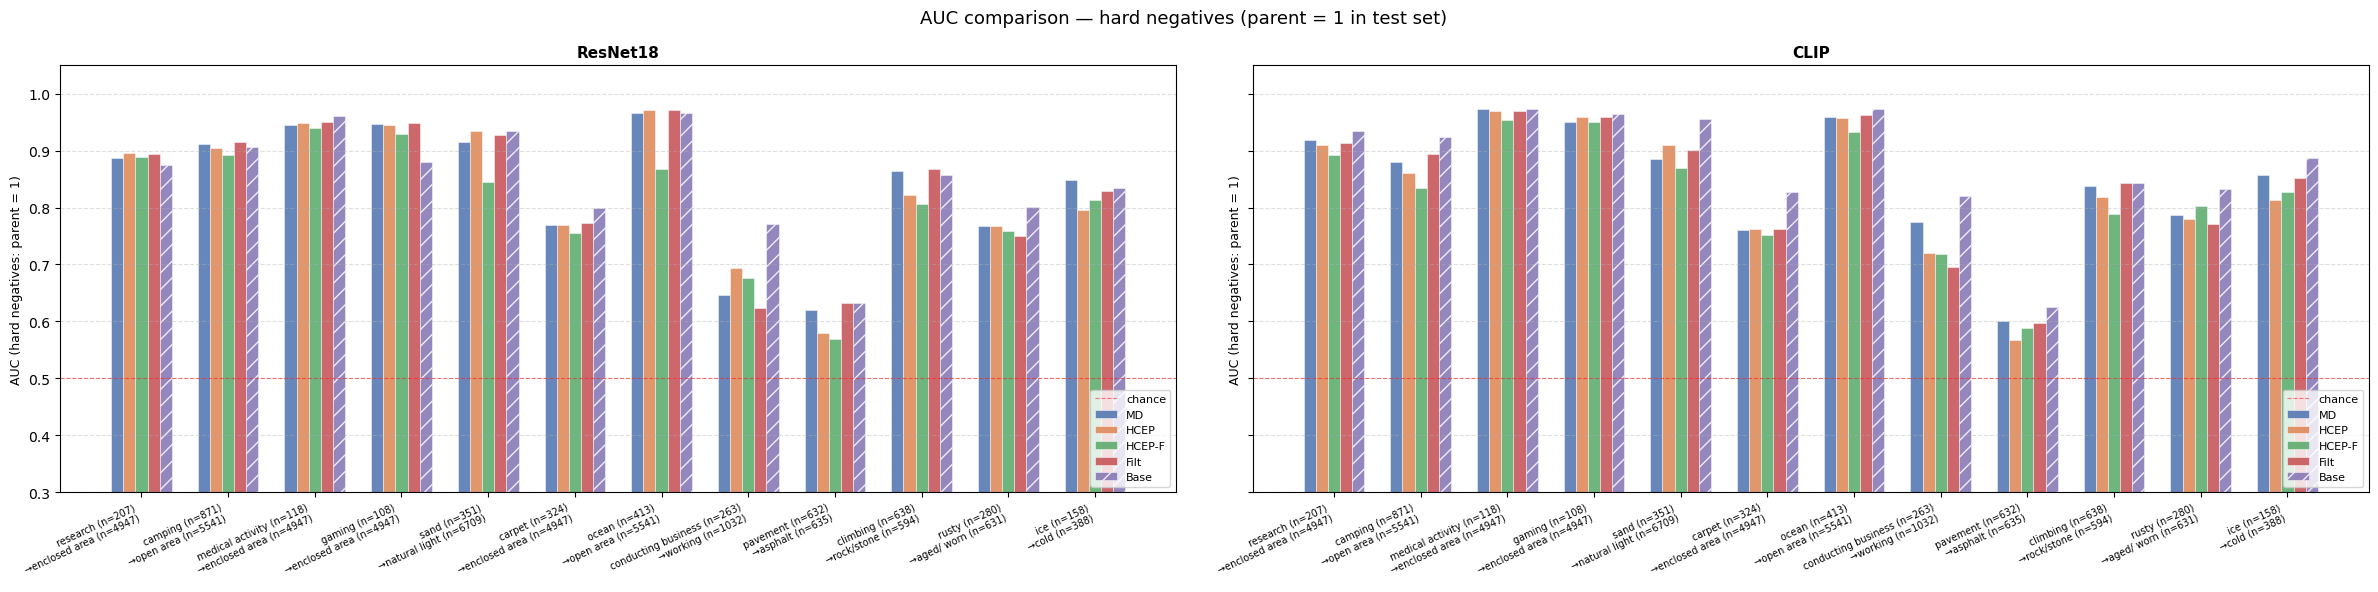

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(24, 6), sharey=True)

for ax, model_name in zip(axes, ["ResNet18", "CLIP"]):
    sub     = df_auc_hard[df_auc_hard["Model"] == model_name]
    labels  = [
        f"{r['Child']} (n={pair_counts[(r['Child'], r['Parent'])][0]})\n"
        f"→{r['Parent']} (n={pair_counts[(r['Child'], r['Parent'])][1]})"
        for _, r in sub.iterrows()
    ]
    x       = np.arange(len(labels))
    w       = 0.14
    offsets = np.linspace(-(len(ALL_METHODS_AUC)-1)/2*w,
                           (len(ALL_METHODS_AUC)-1)/2*w, len(ALL_METHODS_AUC))

    for offset, method in zip(offsets, ALL_METHODS_AUC):
        if method not in sub.columns:
            continue
        vals  = pd.to_numeric(sub[method], errors="coerce").fillna(0).values
        hatch = "//" if method == "Baseline" else None
        ax.bar(x + offset, vals, w, label=SHORT[method],
               color=ALL_COLORS[method], alpha=0.85, edgecolor="white", lw=0.4, hatch=hatch)

    ax.axhline(0.5, color="red", lw=0.8, ls="--", alpha=0.5, label="chance")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7, rotation=25, ha="right")
    ax.set_title(model_name, fontsize=11, fontweight="bold")
    ax.set_ylabel("AUC (hard negatives: parent = 1)", fontsize=9)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="y", ls="--", alpha=0.4)
    ax.set_ylim(0.3, 1.05)

fig.suptitle("AUC comparison — hard negatives (parent = 1 in test set)", fontsize=13)
plt.tight_layout()
plt.show()
